# Universidad de Antioquia
## Facultad de Ingeniería – Departamento de Ingeniería Electrónica y de Telecomunicaciones
### Comunicaciones Digitales

---

# Proyecto Final
## Diseño e implementación de un módem óptico espacio-temporal half-duplex pantalla–cámara

---

### **Estudiantes**
- **Daniel Felipe Yépez Taimal**
- **Juan Manuel Rivera Florez**

### **Docente**
- **Prof. Daniel Ospina Acero, PhD**

### **Semestre**
**2026-1**

---

### Medellín, Colombia
### Universidad de Antioquia

# Transmisión mediante OKK

## Definición inicial del sistema

Para la primera implementación de la Fase A se seleccionó una transmisión mediante **OOK (On-Off Keying)** con codificación **Manchester**, debido a su simplicidad y facilidad de validación en simulación.

Se definió una ventana de transmisión de **1280 × 720 píxeles**, correspondiente a resolución HD, con el fin de disponer de suficiente espacio para la grilla visual y garantizar buena visualización en pantalla.

Cada símbolo se representa mediante una celda de **20 × 20 píxeles**, obteniendo una matriz de **36 filas × 64 columnas**.

La codificación utilizada será:

- **0 → negro**
- **1 → blanco**

y posteriormente cada bit se transformará mediante Manchester:

- **0 → 01**
- **1 → 10**

Con esta configuración se busca validar inicialmente la cadena completa:

**texto → bits → Manchester → OOK → grilla → imagen**,

antes de incorporar marcadores, pilotos y recepción con cámara.

### Conversión del mensaje a ASCII y binario

Como primera etapa del transmisor se implementa la conversión del mensaje de texto a su representación binaria.

Cada carácter del mensaje se transforma a su valor ASCII decimal y posteriormente a binario de 8 bits.

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Mensaje original:
Luisilla, la maravilla, la mas perezocilla

ASCII decimal:
[76, 117, 105, 115, 105, 108, 108, 97, 44, 32, 108, 97, 32, 109, 97, 114, 97, 118, 105, 108, 108, 97, 44, 32, 108, 97, 32, 109, 97, 115, 32, 112, 101, 114, 101, 122, 111, 99, 105, 108, 108, 97]

Secuencia binaria total:
010011000111010101101001011100110110100101101100011011000110000100101100001000000110110001100001001000000110110101100001011100100110000101110110011010010110110001101100011000010010110000100000011011000110000100100000011011010110000101110011001000000111000001100101011100100110010101111010011011110110001101101001011011000110110001100001


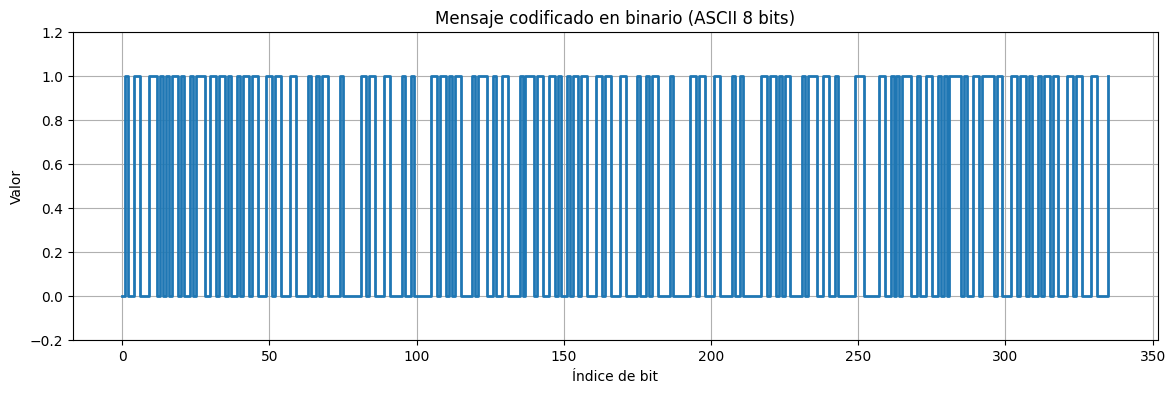

In [142]:
mensaje = "Luisilla, la maravilla, la mas perezocilla"

print("Mensaje original:")
print(mensaje)

ascii_vals = [ord(c) for c in mensaje]

print("\nASCII decimal:")
print(ascii_vals)

binarios = [format(valor, "08b") for valor in ascii_vals]

bits = "".join(binarios)

print("\nSecuencia binaria total:")
print(bits)

bits_array = np.array([int(b) for b in bits])

plt.figure(figsize=(14,4))

plt.step(
    np.arange(len(bits_array)),
    bits_array,
    where="post",
    linewidth=2
)

plt.ylim(-0.2, 1.2)

plt.xlabel("Índice de bit")
plt.ylabel("Valor")

plt.title("Mensaje codificado en binario (ASCII 8 bits)")

plt.grid(True)

plt.show()


### Codificación Manchester

En esta etapa se aplica codificación Manchester a la secuencia binaria obtenida desde el mensaje ASCII.

La convención utilizada es:

- Bit `0` → `01`
- Bit `1` → `10`

Con esta codificación, cada bit original se representa mediante dos bits codificados. Esto permite balancear el brillo promedio de la transmisión y evita secuencias largas de símbolos iguales.

In [143]:
def codificar_manchester(bits_array):
    bits_manchester = []

    for bit in bits_array:
        if bit == 0:
            bits_manchester.extend([0, 1])
        elif bit == 1:
            bits_manchester.extend([1, 0])
        else:
            raise ValueError("La secuencia solo debe contener bits 0 o 1.")

    return np.array(bits_manchester)


bits_manchester = codificar_manchester(bits_array)

print("Cantidad de bits originales:", len(bits_array))
print("Cantidad de bits Manchester:", len(bits_manchester))

print("\nPrimeros bits originales:")
print(bits_array[:32])

print("\nPrimeros bits Manchester:")
print(bits_manchester[:64])

Cantidad de bits originales: 336
Cantidad de bits Manchester: 672

Primeros bits originales:
[0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 0 1 0 0 1 0 1 1 1 0 0 1 1]

Primeros bits Manchester:
[0 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 1 0 1
 0 0 1 1 0 0 1 0 1 1 0 0 1 1 0 1 0 1 0 0 1 0 1 1 0 1 0]


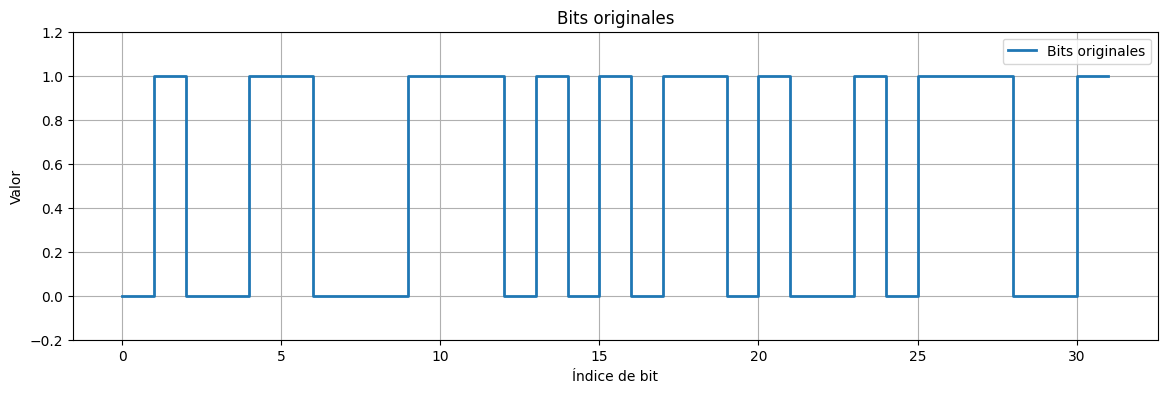

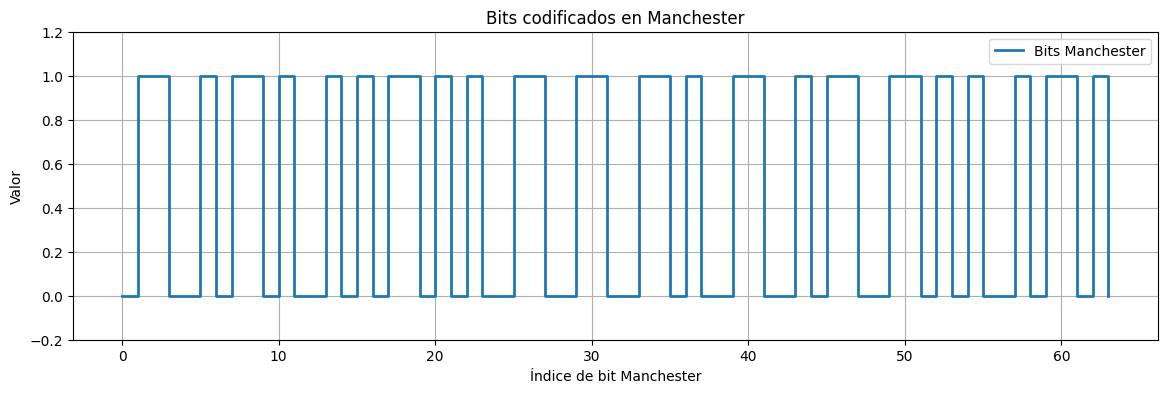

In [144]:
num_bits_mostrar = 32

plt.figure(figsize=(14,4))
plt.step(
    np.arange(num_bits_mostrar),
    bits_array[:num_bits_mostrar],
    where="post",
    linewidth=2,
    label="Bits originales"
)

plt.ylim(-0.2, 1.2)
plt.xlabel("Índice de bit")
plt.ylabel("Valor")
plt.title("Bits originales")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(14,4))
plt.step(
    np.arange(2*num_bits_mostrar),
    bits_manchester[:2*num_bits_mostrar],
    where="post",
    linewidth=2,
    label="Bits Manchester"
)

plt.ylim(-0.2, 1.2)
plt.xlabel("Índice de bit Manchester")
plt.ylabel("Valor")
plt.title("Bits codificados en Manchester")
plt.grid(True)
plt.legend()
plt.show()

### Modulación OOK

En esta etapa se realiza la modulación OOK sobre la secuencia codificada en Manchester.

Cada bit Manchester se convierte en un nivel de intensidad en escala de grises:

- `0` → intensidad baja
- `1` → intensidad alta

Estos niveles serán posteriormente ubicados dentro de la grilla espacial de transmisión.

In [145]:
nivel_bajo = 0      # negro
nivel_alto = 255    # blanco

simbolos_ook = np.where(bits_manchester == 0, nivel_bajo, nivel_alto)

print("Cantidad de símbolos OOK:", len(simbolos_ook))

print("\nPrimeros bits Manchester:")
print(bits_manchester[:32])

print("\nPrimeros símbolos OOK:")
print(simbolos_ook[:32])

Cantidad de símbolos OOK: 672

Primeros bits Manchester:
[0 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0]

Primeros símbolos OOK:
[  0 255 255   0   0 255   0 255 255   0 255   0   0 255   0 255   0 255
 255   0 255   0 255   0   0 255 255   0   0 255 255   0]


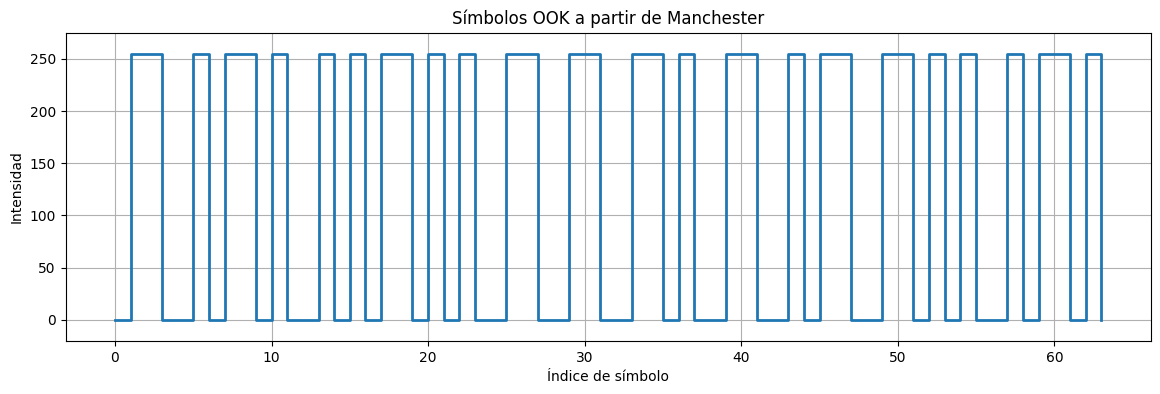

In [146]:
num_simbolos_mostrar = 64

plt.figure(figsize=(14,4))

plt.step(
    np.arange(num_simbolos_mostrar),
    simbolos_ook[:num_simbolos_mostrar],
    where="post",
    linewidth=2
)

plt.ylim(-20, 275)
plt.xlabel("Índice de símbolo")
plt.ylabel("Intensidad")
plt.title("Símbolos OOK a partir de Manchester")
plt.grid(True)

plt.show()

### Mapeo de símbolos en la matriz de transmisión

En esta etapa los símbolos OOK se ubican espacialmente dentro de la grilla de transmisión.

La ventana definida es de 1280 × 720 píxeles, con celdas de 20 × 20 píxeles. Por tanto, se obtiene una matriz de 36 filas por 64 columnas.

Cada posición de la matriz representa una celda visual que transporta un símbolo OOK.

In [147]:
ancho_img = 1280
alto_img = 720

tam_celda = 20

num_columnas = ancho_img // tam_celda
num_filas = alto_img // tam_celda

total_celdas = num_filas * num_columnas

print("Número de filas:", num_filas)
print("Número de columnas:", num_columnas)
print("Total de celdas:", total_celdas)

if len(simbolos_ook) > total_celdas:
    raise ValueError("El mensaje es demasiado largo para la grilla definida.")

matriz_tx = np.zeros(total_celdas, dtype=np.uint8)

matriz_tx[:len(simbolos_ook)] = simbolos_ook

matriz_tx = matriz_tx.reshape((num_filas, num_columnas))

print("Forma de la matriz de transmisión:", matriz_tx.shape)

Número de filas: 36
Número de columnas: 64
Total de celdas: 2304
Forma de la matriz de transmisión: (36, 64)


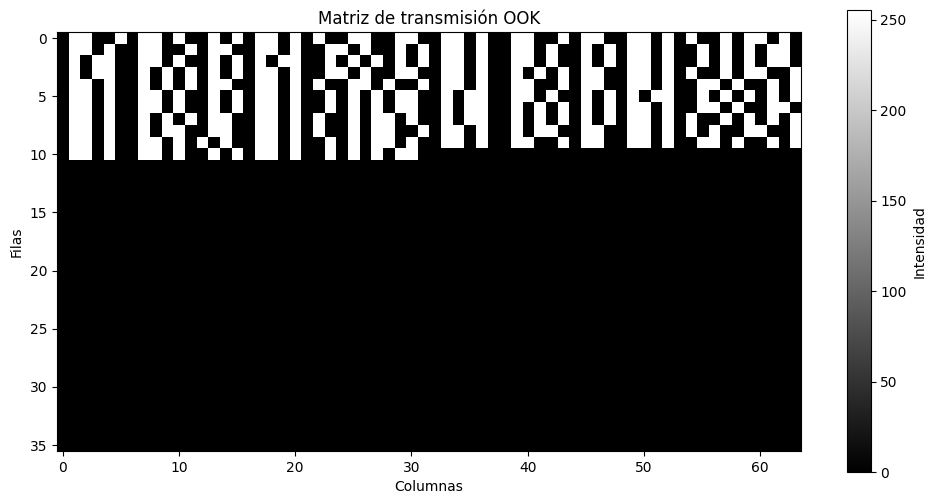

In [148]:
plt.figure(figsize=(12,6))

plt.imshow(matriz_tx, cmap="gray", vmin=0, vmax=255)

plt.title("Matriz de transmisión OOK")
plt.xlabel("Columnas")
plt.ylabel("Filas")

plt.colorbar(label="Intensidad")
plt.show()

### Generación del frame de transmisión

En esta etapa se convierte la matriz de símbolos en una imagen real.

Cada símbolo OOK de la matriz se expande a una celda cuadrada de 20 × 20 píxeles. De esta forma, la matriz de 36 × 64 celdas se transforma en una imagen de 720 × 1280 píxeles, lista para ser visualizada o guardada como frame de transmisión.

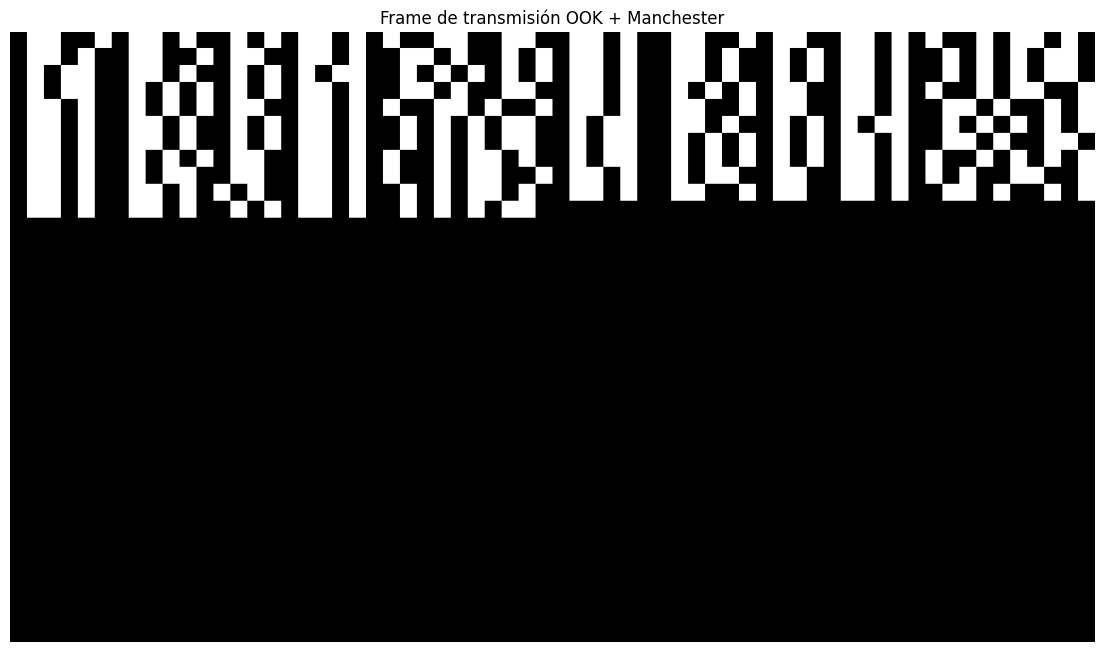

In [149]:
frame_tx = np.kron(
    matriz_tx,
    np.ones((tam_celda, tam_celda), dtype=np.uint8)
)

plt.figure(figsize=(14,8))

plt.imshow(frame_tx, cmap="gray", vmin=0, vmax=255)

plt.title("Frame de transmisión OOK + Manchester")
plt.axis("off")

plt.show()

### Integración del preámbulo

Antes de codificar el mensaje se agrega una secuencia de preámbulo conocida.

Su función es facilitar en el receptor la detección del inicio de la trama y la sincronización antes de procesar los datos útiles.

Para esta primera implementación se define el preámbulo:

1010101011110000

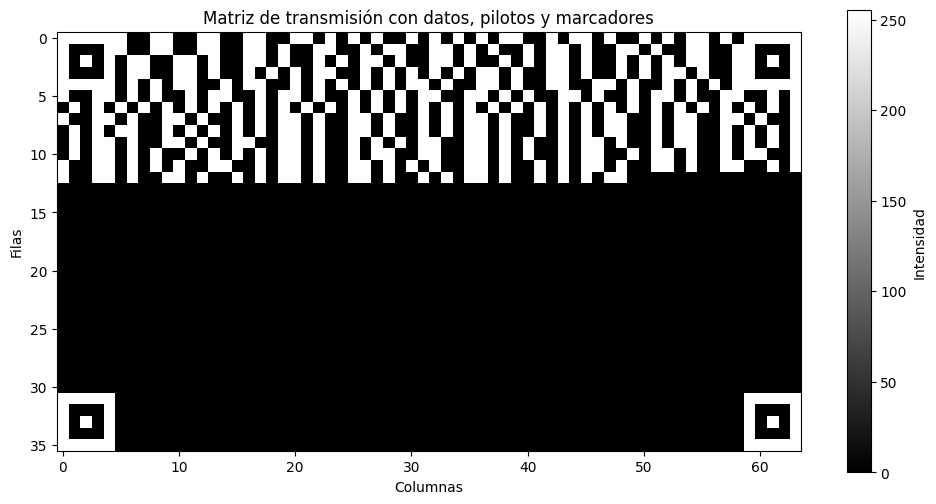

In [150]:
preambulo = "1010101011110000"

preambulo_array = np.array(
    [int(b) for b in preambulo],
    dtype=np.uint8
)

bits_tx = np.concatenate(
    [preambulo_array, bits_array]
)

# Regenerar Manchester usando preámbulo + mensaje
bits_manchester = codificar_manchester(bits_tx)

# Regenerar OOK
nivel_bajo = 0
nivel_alto = 255

simbolos_ook = np.where(bits_manchester == 0, nivel_bajo, nivel_alto)

tam_marcador = 5  # marcador de 5x5 celdas

# Patrón tipo finder simple
marcador = np.array([
    [255, 255, 255, 255, 255],
    [255,   0,   0,   0, 255],
    [255,   0, 255,   0, 255],
    [255,   0,   0,   0, 255],
    [255, 255, 255, 255, 255]
], dtype=np.uint8)

def insertar_marcadores(matriz):
    matriz = matriz.copy()

    # Superior izquierdo
    matriz[0:5, 0:5] = marcador

    # Superior derecho
    matriz[0:5, -5:] = marcador

    # Inferior izquierdo
    matriz[-5:, 0:5] = marcador

    # Inferior derecho
    matriz[-5:, -5:] = marcador

    return matriz

def insertar_pilotos(matriz):
    matriz = matriz.copy()

    fila_pilotos = 6

    for col in range(num_columnas):
        if col % 2 == 0:
            matriz[fila_pilotos, col] = 0
        else:
            matriz[fila_pilotos, col] = 255

    return matriz

matriz_tx = np.zeros((num_filas, num_columnas), dtype=np.uint8)

mascara_datos = np.ones((num_filas, num_columnas), dtype=bool)

mascara_datos[0:5, 0:5] = False
mascara_datos[0:5, -5:] = False
mascara_datos[-5:, 0:5] = False
mascara_datos[-5:, -5:] = False

fila_pilotos = 6
mascara_datos[fila_pilotos, :] = False

posiciones_datos = np.argwhere(mascara_datos)

if len(simbolos_ook) > len(posiciones_datos):
    raise ValueError("El mensaje es demasiado largo para la grilla con marcadores y pilotos.")

for simbolo, (fila, columna) in zip(simbolos_ook, posiciones_datos):
    matriz_tx[fila, columna] = simbolo

matriz_tx = insertar_pilotos(matriz_tx)
matriz_tx = insertar_marcadores(matriz_tx)

plt.figure(figsize=(12,6))

plt.imshow(matriz_tx, cmap="gray", vmin=0, vmax=255)

plt.title("Matriz de transmisión con datos, pilotos y marcadores")
plt.xlabel("Columnas")
plt.ylabel("Filas")

plt.colorbar(label="Intensidad")
plt.show()


In [151]:
frame_tx = np.kron(
    matriz_tx,
    np.ones((tam_celda, tam_celda), dtype=np.uint8)
)

plt.imsave(
    "frame_tx_ook_manchester_completo.png",
    frame_tx,
    cmap="gray",
    vmin=0,
    vmax=255
)

print("Frame guardado como: frame_tx_ook_manchester_completo.png")


Frame guardado como: frame_tx_ook_manchester_completo.png


### Decodificador ideal del frame

En esta etapa se verifica el lazo digital de extremo a extremo usando la imagen generada previamente.

El decodificador ideal lee el frame `.png`, lo divide nuevamente en celdas de 20 × 20 píxeles, calcula la intensidad promedio de cada celda y recupera los símbolos OOK.

Posteriormente se eliminan las posiciones reservadas para marcadores y pilotos, se decodifica Manchester, se retira el preámbulo y se reconstruye el mensaje ASCII original.

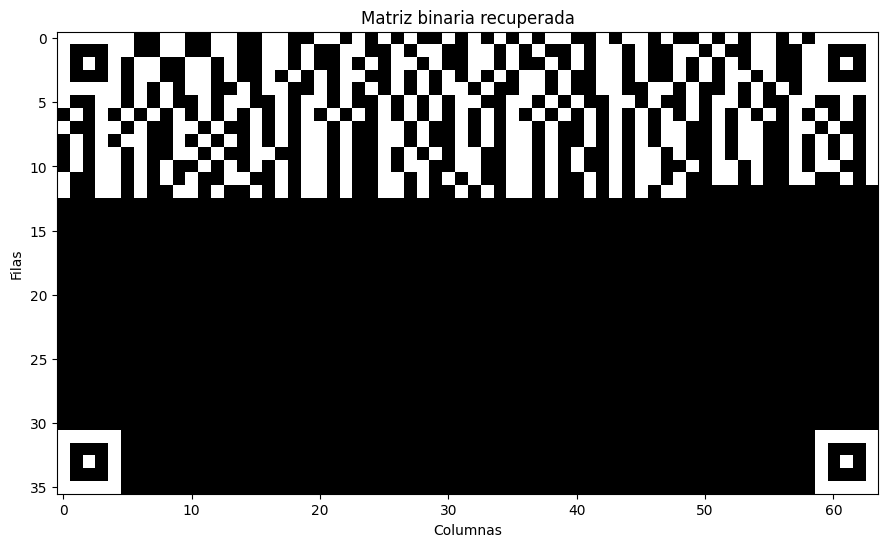

In [152]:
ruta_frame = "frame_tx_ook_manchester_completo.png"

img_rx = cv2.imread(ruta_frame, cv2.IMREAD_GRAYSCALE)

if img_rx is None:
    raise FileNotFoundError("No se pudo leer la imagen. Verifica la ruta del archivo.")

ancho_img = 1280
alto_img = 720
tam_celda = 20

num_columnas = ancho_img // tam_celda
num_filas = alto_img // tam_celda

matriz_rx = np.zeros((num_filas, num_columnas), dtype=np.float32)

for fila in range(num_filas):
    for col in range(num_columnas):

        y0 = fila * tam_celda
        y1 = y0 + tam_celda

        x0 = col * tam_celda
        x1 = x0 + tam_celda

        celda = img_rx[y0:y1, x0:x1]

        matriz_rx[fila, col] = np.mean(celda)

umbral = 127

matriz_bits_rx = (matriz_rx > umbral).astype(np.uint8)

plt.figure(figsize=(12,6))
plt.imshow(matriz_bits_rx, cmap="gray", vmin=0, vmax=1)
plt.title("Matriz binaria recuperada")
plt.xlabel("Columnas")
plt.ylabel("Filas")
plt.show()

In [153]:
mascara_datos = np.ones((num_filas, num_columnas), dtype=bool)

mascara_datos[0:5, 0:5] = False
mascara_datos[0:5, -5:] = False
mascara_datos[-5:, 0:5] = False
mascara_datos[-5:, -5:] = False

fila_pilotos = 6
mascara_datos[fila_pilotos, :] = False

bits_manchester_rx = matriz_bits_rx[mascara_datos]

bits_manchester_rx = bits_manchester_rx[:len(simbolos_ook)]

def decodificar_manchester(bits_manchester):
    bits_decodificados = []

    if len(bits_manchester) % 2 != 0:
        raise ValueError("La secuencia Manchester debe tener longitud par.")

    for i in range(0, len(bits_manchester), 2):
        par = bits_manchester[i:i+2]

        if np.array_equal(par, [0, 1]):
            bits_decodificados.append(0)
        elif np.array_equal(par, [1, 0]):
            bits_decodificados.append(1)
        else:
            # Par inválido: 00 o 11
            bits_decodificados.append(-1)

    return np.array(bits_decodificados)


bits_rx = decodificar_manchester(bits_manchester_rx)

errores_manchester = np.sum(bits_rx == -1)
print("Errores Manchester:", errores_manchester)

Errores Manchester: 0


### Constelación de píxeles (niveles de intensidad)

Se analiza la intensidad promedio medida en cada celda de datos del frame recibido.

En OOK ideal se espera observar dos agrupaciones principales:

- valores cercanos a negro (bit 0)
- valores cercanos a blanco (bit 1)

Esta distribución permite verificar la separación entre símbolos antes de aplicar el umbral de decisión.

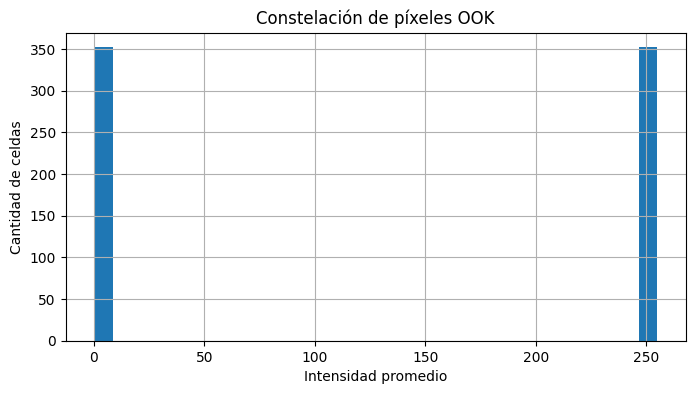

In [154]:
# Intensidades medidas solo en datos
intensidades_rx = matriz_rx[mascara_datos]

# recortar solo símbolos transmitidos
intensidades_rx = intensidades_rx[:len(simbolos_ook)]

plt.figure(figsize=(8,4))

plt.hist(
    intensidades_rx,
    bins=30
)

plt.xlabel("Intensidad promedio")
plt.ylabel("Cantidad de celdas")

plt.title("Constelación de píxeles OOK")

plt.grid(True)

plt.show()

### Reconstrucción del Mensaje

In [155]:
preambulo = "1010101011110000"
len_preambulo = len(preambulo)

preambulo_rx = bits_rx[:len_preambulo]
datos_rx = bits_rx[len_preambulo:]

print("Preámbulo recibido:")
print(preambulo_rx)

print("Preámbulo esperado:")
print(np.array([int(b) for b in preambulo]))


datos_rx = datos_rx[datos_rx != -1]

num_bits_validos = (len(datos_rx) // 8) * 8
datos_rx = datos_rx[:num_bits_validos]

caracteres = []

for i in range(0, len(datos_rx), 8):
    byte = datos_rx[i:i+8]

    valor_ascii = int("".join(str(b) for b in byte), 2)

    if valor_ascii == 0:
        break

    caracteres.append(chr(valor_ascii))

mensaje_rx = "".join(caracteres)

print("\nMensaje recuperado:")
print(mensaje_rx)

Preámbulo recibido:
[1 0 1 0 1 0 1 0 1 1 1 1 0 0 0 0]
Preámbulo esperado:
[1 0 1 0 1 0 1 0 1 1 1 1 0 0 0 0]

Mensaje recuperado:
Luisilla, la maravilla, la mas perezocilla
